# 03 — Feature Engineering
**Prueba Técnica · Data Scientist Jr. · Solventa**

Este notebook construye las features finales para el modelo partiendo del dataset limpio.
Cierra con una revalidación del Information Value (IV) sobre las variables construidas
para confirmar que la transformación no degradó la señal predictiva.

---
**Contenido**
1. Carga y limpieza
2. Agrupación de categorías poco representadas
3. Transformaciones de distribuciones sesgadas
4. Construcción de nuevas variables (ratios, flag, bucket)
5. WoE Encoding
6. Selección final de variables
7. Visualizaciones
8. ✅ Validación post-FE — IV recalculado


## 0. Librerías y configuración

In [32]:
import warnings
import importlib.util
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import FuncFormatter

warnings.filterwarnings("ignore")

# ── Configuración visual ──────────────────────────────────────────────────
COLOR_BUENO = "#4C72B0"
COLOR_MALO  = "#C44E52"
PALETTE     = [COLOR_BUENO, COLOR_MALO]

plt.rcParams.update({
    "figure.facecolor" : "white",
    "axes.facecolor"   : "#F7F7F7",
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "font.family"      : "DejaVu Sans",
    "axes.titlesize"   : 11,
    "axes.labelsize"   : 10,
})

print("✓ Librerías cargadas")

✓ Librerías cargadas


## 1. Carga y limpieza

Se reutiliza la función `limpiar_datos()` del script `01_limpieza_datos.py`.
El dataset se ordena cronológicamente por `FFECHA` y se define la variable objetivo.


In [33]:
# Importar función de limpieza desde el script 01
_spec = importlib.util.spec_from_file_location(
    "limpieza", Path("01_limpieza_datos.py")
)
_mod = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(_mod)
limpiar_datos = _mod.limpiar_datos

# Carga y limpieza
df_raw      = pd.read_excel("ProductoNuevo.xlsx")
df_clean, _ = limpiar_datos(df_raw, verbose=False)

# Ordenar cronológicamente — requerimiento del split temporal
df_sorted    = df_clean.sort_values("FFECHA").reset_index(drop=True)
TARGET       = "Mora60"
TASA_GLOBAL  = df_clean[TARGET].mean()

print(f"Dataset limpio : {df_sorted.shape[0]:,} registros | {df_sorted.shape[1]} columnas")
print(f"Tasa de default: {TASA_GLOBAL:.2%}  (Malos: {df_sorted[TARGET].sum()} | Buenos: {(df_sorted[TARGET]==0).sum()})")

Dataset limpio : 4,315 registros | 24 columnas
Tasa de default: 11.68%  (Malos: 504 | Buenos: 3811)


## 2. Agrupación de categorías poco representadas

### 2.1 `Nivel_Academico` — ESPECIALIZACIÓN → UNIVERSITARIO_PLUS

**Hallazgo EDA:** ESPECIALIZACIÓN tiene solo 55 registros y 4 malos (mora 7.3%),
perfil casi idéntico a UNIVERSITARIO (mora 8.8%). Con tan pocos eventos el modelo
no puede aprender un patrón estable para esa categoría.

**Acción:** fusionar ambas bajo `UNIVERSITARIO_PLUS`. `OTROS` se mantiene separado
por tener la mora más alta (18.2%).

---

### 2.2 `Estado_Civil` — DIVORCIADO + VIUDO → CASADO_ESTABLE

**Hallazgo EDA:** DIVORCIADO (n=87, mora=9.2%) y VIUDO (n=36, mora=8.3%) tienen
comportamiento de riesgo prácticamente igual a CASADO (mora=10.4%), con muy pocos
malos (8 y 3 respectivamente). Incluirlos como categorías separadas agrega
dimensionalidad sin aportar señal predictiva.

**Acción:** fusionar los tres bajo `CASADO_ESTABLE`. `OTROS` se mantiene (mora=17.6%).


In [34]:
# ── Nivel_Academico ───────────────────────────────────────────────────────
mapa_nivel = {
    "BACHILLER"       : "BACHILLER",
    "TECNÓLOGO"       : "TECNÓLOGO",
    "UNIVERSITARIO"   : "UNIVERSITARIO_PLUS",
    "ESPECIALIZACIÓN" : "UNIVERSITARIO_PLUS",
    "OTROS"           : "OTROS",
}

# ── Estado_Civil ──────────────────────────────────────────────────────────
mapa_civil = {
    "SOLTERO"    : "SOLTERO",
    "CASADO"     : "CASADO_ESTABLE",
    "DIVORCIADO" : "CASADO_ESTABLE",
    "VIUDO"      : "CASADO_ESTABLE",
    "OTROS"      : "OTROS",
}

# Aplicar sobre df_sorted (se usará dentro de feature_engineering)
df_sorted["nivel_academico_agrup"] = df_sorted["Nivel_Academico"].map(mapa_nivel).fillna("OTROS")
df_sorted["estado_civil_agrup"]    = df_sorted["Estado_Civil"].map(mapa_civil).fillna("OTROS")

# Comparación antes / después
for col_orig, col_agrup in [("Nivel_Academico","nivel_academico_agrup"),
                             ("Estado_Civil","estado_civil_agrup")]:
    print(f"\n{'='*55}")
    print(f"  {col_orig}")
    print(f"{'─'*55}")
    stats = (df_sorted.groupby(col_agrup)[TARGET]
             .agg(["count","mean"])
             .rename(columns={"count":"n","mean":"mora"})
             .sort_values("mora", ascending=False))
    stats["n_%"] = (stats["n"] / len(df_sorted) * 100).round(1)
    print(stats[["n","n_%","mora"]].to_string())


  Nivel_Academico
───────────────────────────────────────────────────────
                          n   n_%      mora
nivel_academico_agrup                      
OTROS                   181   4.2  0.182320
BACHILLER              1450  33.6  0.146207
TECNÓLOGO              1359  31.5  0.105224
UNIVERSITARIO_PLUS     1325  30.7  0.087547

  Estado_Civil
───────────────────────────────────────────────────────
                       n   n_%      mora
estado_civil_agrup                      
OTROS                671  15.6  0.175857
SOLTERO             2749  63.7  0.107312
CASADO_ESTABLE       895  20.7  0.101676


## 3. Transformaciones de distribuciones sesgadas

`TiempoClienteMeses` y `Tiempo_SistemaFro` presentan distribuciones fuertemente
sesgadas a la derecha con alta concentración en cero (34% y 62% respectivamente).

Se aplica `log1p(x) = log(x + 1)` que:
- Maneja los ceros sin producir `-inf`
- Comprime la escala de la cola derecha
- Preserva la señal diferencial en los extremos
- No elimina ningún outlier — los incorpora de forma más balanceada


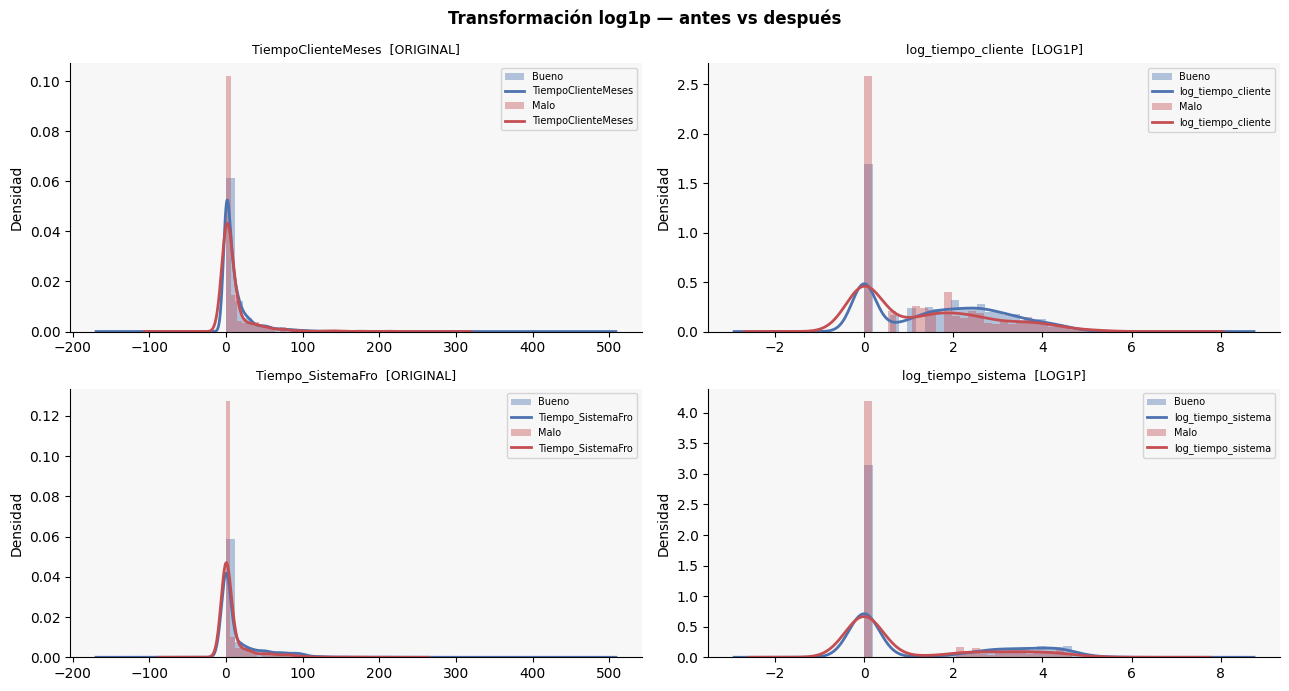

In [35]:
df_sorted["log_tiempo_cliente"] = np.log1p(df_sorted["TiempoClienteMeses"])
df_sorted["log_tiempo_sistema"] = np.log1p(df_sorted["Tiempo_SistemaFro"])

# Comparación visual antes / después
fig, axes = plt.subplots(2, 2, figsize=(13, 7))
fig.suptitle("Transformación log1p — antes vs después", fontsize=12, fontweight="bold")

pares = [
    ("TiempoClienteMeses", "log_tiempo_cliente"),
    ("Tiempo_SistemaFro",  "log_tiempo_sistema"),
]
for i, (col_orig, col_log) in enumerate(pares):
    for j, col in enumerate([col_orig, col_log]):
        ax = axes[i][j]
        for val, label, color in zip([0,1], ["Bueno","Malo"], PALETTE):
            s = df_sorted[df_sorted[TARGET]==val][col].dropna()
            ax.hist(s, bins=30, alpha=0.4, color=color,
                    density=True, label=label, edgecolor="none")
            s.plot.kde(ax=ax, color=color, linewidth=2)
        titulo = "ORIGINAL" if j == 0 else "LOG1P"
        ax.set_title(f"{col}  [{titulo}]", fontsize=9)
        ax.set_ylabel("Densidad")
        ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

## 4. Construcción de nuevas variables

### 4.1 Capacidad de pago
Proporción del ingreso disponible tras gastos familiares.
Capeado a 0 en los 6 casos donde gastos > ingresos.

### 4.2 Carga financiera total
Suma de gastos familiares y arriendo sobre el ingreso.
Complementa a `PORCEND` con la presión de gasto corriente del hogar.

### 4.3 Flag cliente nuevo
`Tiempo_SistemaFro = 0` en el 62% de los registros.
El flag hace explícita esta condición para modelos lineales,
donde `log(0+1) = 0` no se distingue de un valor observado bajo.

### 4.4 Bucket de edad
Segmentación por ciclo de vida crediticio:
- **18-25**: inicio laboral, menor estabilidad de ingresos
- **26-35**: consolidación profesional
- **36-50**: madurez financiera
- **51+**: pre-jubilación, ingresos más predecibles

Captura relaciones no lineales entre edad y mora que una variable
continua modelaría con dificultad.


In [36]:
# 4.1 Capacidad de pago
df_sorted["capacidad_pago"] = (
    (df_sorted["Ingresos"] - df_sorted["GastosFamiliares"]) / df_sorted["Ingresos"]
).clip(lower=0)

# 4.2 Carga total
df_sorted["carga_total"] = (
    (df_sorted["GastosFamiliares"] + df_sorted["GastoArriendo"]) / df_sorted["Ingresos"]
)

# 4.3 Flag cliente nuevo
df_sorted["es_cliente_nuevo"] = (df_sorted["Tiempo_SistemaFro"] == 0).astype(int)

# 4.4 Bucket edad
bins_edad   = [0, 25, 35, 50, 100]
labels_edad = ["18-25", "26-35", "36-50", "51+"]
df_sorted["bucket_edad"] = pd.cut(
    df_sorted["Edad"], bins=bins_edad, labels=labels_edad, right=True
).astype(str)

# Resumen: mora por bucket_edad
print("Mora por bucket de edad:")
print(df_sorted.groupby("bucket_edad")[TARGET]
      .agg(["count","mean"])
      .rename(columns={"count":"n","mean":"mora"})
      .round(3))

Mora por bucket de edad:
                n   mora
bucket_edad             
18-25         675  0.129
26-35        2279  0.116
36-50         968  0.116
51+           393  0.104


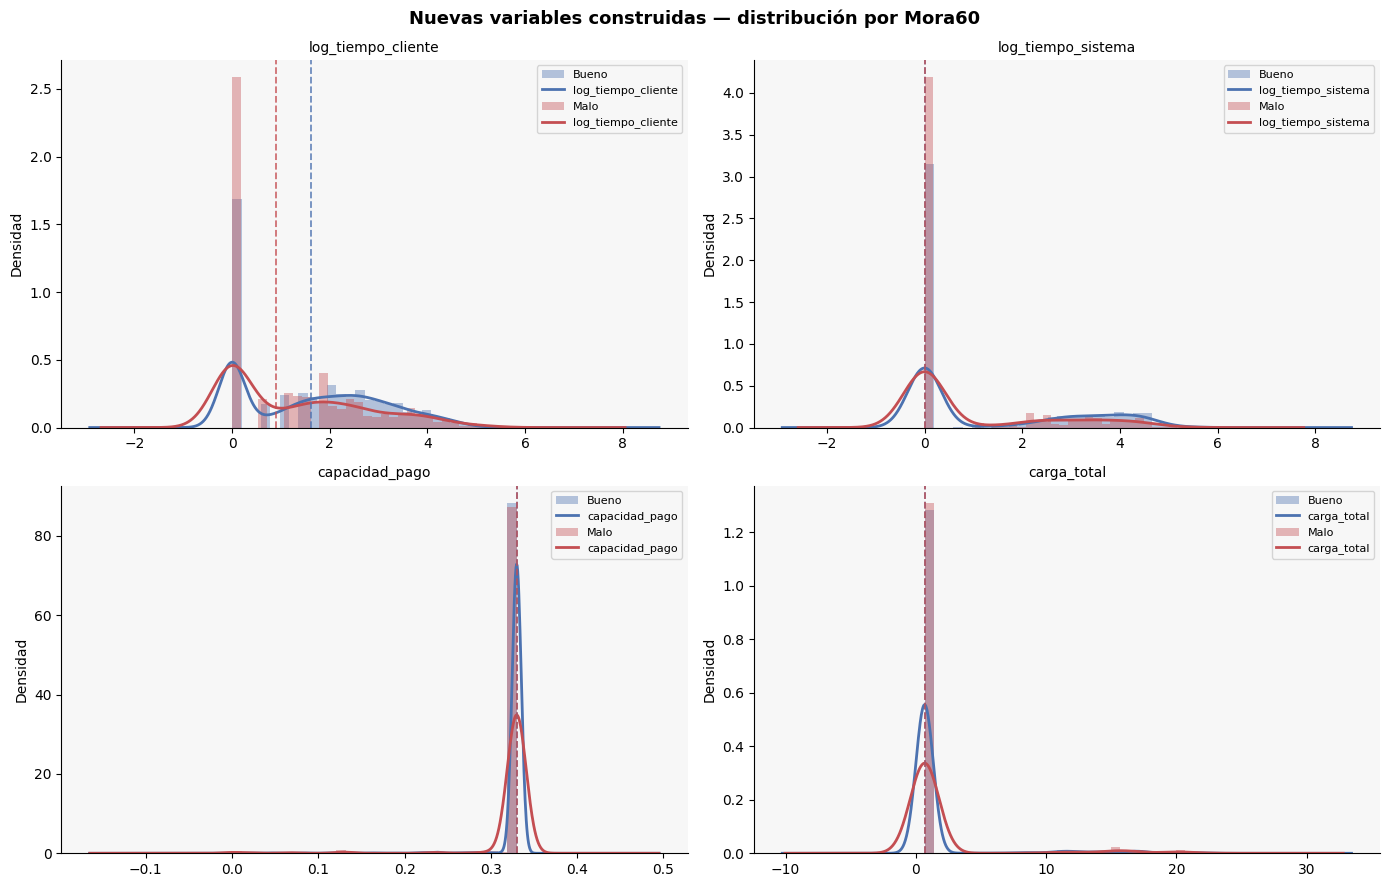

In [37]:
NUEVAS = ["log_tiempo_cliente", "log_tiempo_sistema", "capacidad_pago", "carga_total"]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Nuevas variables construidas — distribución por Mora60",
             fontsize=13, fontweight="bold")
axes = axes.flatten()

for i, col in enumerate(NUEVAS):
    ax = axes[i]
    for val, label, color in zip([0,1], ["Bueno","Malo"], PALETTE):
        s = df_sorted[df_sorted[TARGET]==val][col].dropna()
        ax.hist(s, bins=30, alpha=0.4, color=color,
                density=True, label=label, edgecolor="none")
        s.plot.kde(ax=ax, color=color, linewidth=2)
    med_b = df_sorted[df_sorted[TARGET]==0][col].median()
    med_m = df_sorted[df_sorted[TARGET]==1][col].median()
    ax.axvline(med_b, color=COLOR_BUENO, linestyle="--", linewidth=1.3, alpha=0.8)
    ax.axvline(med_m, color=COLOR_MALO,  linestyle="--", linewidth=1.3, alpha=0.8)
    ax.set_title(col, fontsize=10)
    ax.set_ylabel("Densidad")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 5. WoE Encoding

El **Weight of Evidence** reemplaza cada categoría por:

$$WoE_i = \ln\left(\frac{Dist\_Buenos_i}{Dist\_Malos_i}\right)$$

**Ventajas sobre One-Hot Encoding:**
- No expande la dimensionalidad (1 columna por variable)
- Incorpora directamente la relación ordinal con el target
- Robusto ante categorías con poca masa
- Compatible con modelos lineales y de árboles

⚠️ **Punto clave anti-leakage:** el WoE se aprende **exclusivamente sobre train**
y se aplica en test con los mismos valores — nunca se recalcula sobre test.


In [38]:
def calcular_woe_map(df_train, col, target):
    """
    Aprende el mapa WoE desde el conjunto de entrenamiento.
    Aplica suavizado de Laplace (0.5) para evitar log(0).
    """
    total_b = (df_train[target] == 0).sum()
    total_m = (df_train[target] == 1).sum()
    woe_map = {}
    for cat in df_train[col].unique():
        mask   = df_train[col] == cat
        n_b    = (df_train[target][mask] == 0).sum()
        n_m    = (df_train[target][mask] == 1).sum()
        dist_b = max(n_b, 0.5) / total_b
        dist_m = max(n_m, 0.5) / total_m
        woe_map[str(cat)] = float(np.log(dist_b / dist_m))
    return woe_map

def aplicar_woe(df, col, woe_map):
    """Aplica un mapa WoE ya aprendido. Categorías no vistas → 0."""
    return df[col].astype(str).map(woe_map).fillna(0.0)

# Variables a encodear
CAT_WOE = [
    "nivel_academico_agrup",
    "estado_civil_agrup",
    "Genero",
    "bucket_edad",
]

# Los mapas se aprenderán en train dentro de la función principal
# Aquí calculamos sobre todo el dataset solo para la visualización
woe_maps_viz = {}
for col in CAT_WOE:
    woe_maps_viz[col] = calcular_woe_map(df_sorted, col, TARGET)
    print(f"WoE — {col}:")
    for k, v in sorted(woe_maps_viz[col].items(), key=lambda x: x[1]):
        print(f"    {k:<25} {v:>7.4f}")
    print()

WoE — nivel_academico_agrup:
    OTROS                     -0.5224
    BACHILLER                 -0.2584
    TECNÓLOGO                  0.1174
    UNIVERSITARIO_PLUS         0.3209

WoE — estado_civil_agrup:
    OTROS                     -0.4784
    SOLTERO                    0.0954
    CASADO_ESTABLE             0.1557

WoE — Genero:
    MASCULINO                 -0.2283
    FEMENINO                   0.3450

WoE — bucket_edad:
    18-25                     -0.1123
    26-35                      0.0094
    36-50                      0.0107
    51+                        0.1270



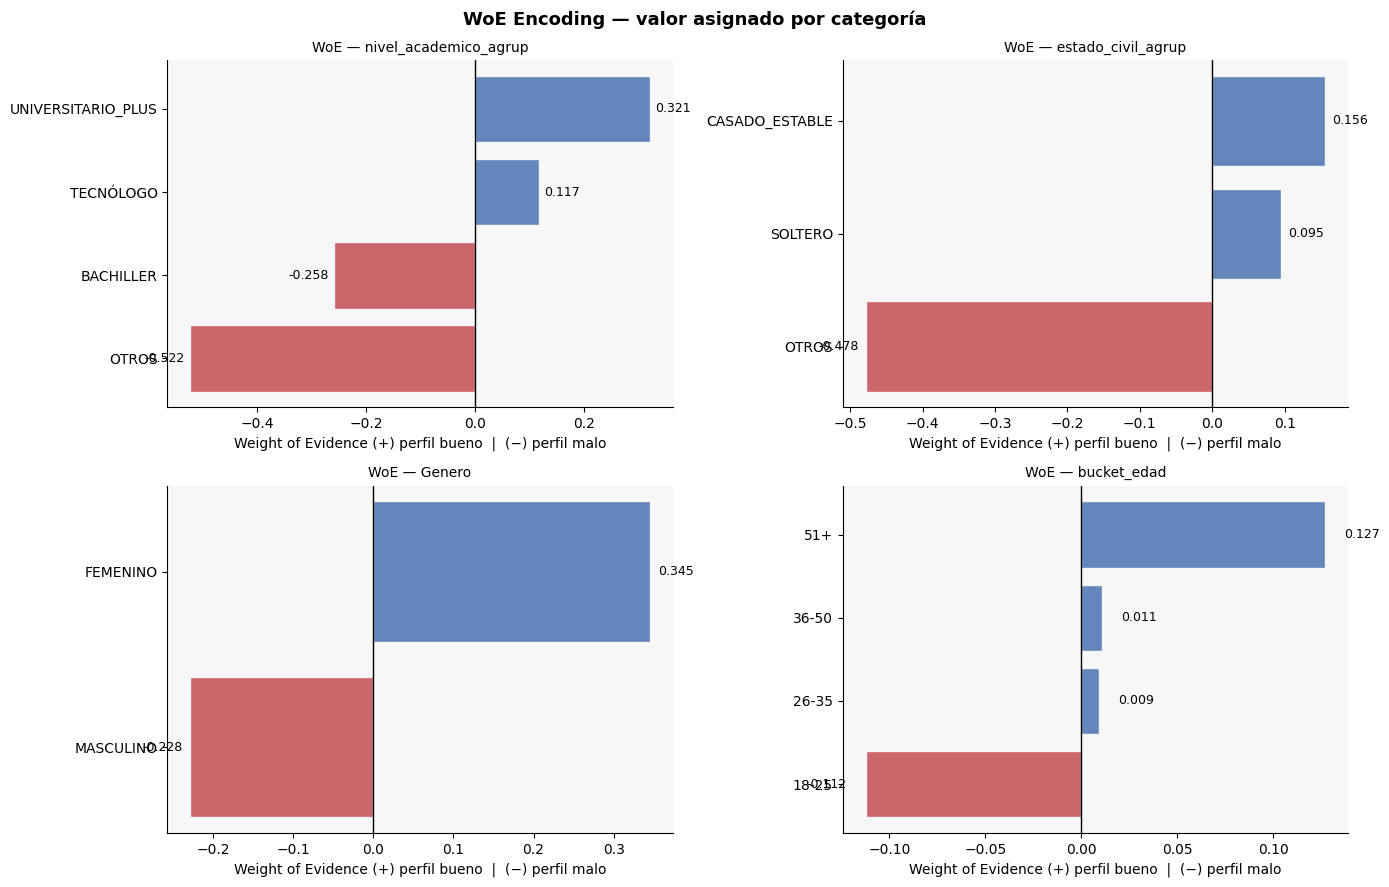

In [39]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("WoE Encoding — valor asignado por categoría",
             fontsize=13, fontweight="bold")
axes = axes.flatten()

for i, col in enumerate(CAT_WOE):
    ax      = axes[i]
    woe_df  = (pd.Series(woe_maps_viz[col])
                 .reset_index()
                 .rename(columns={"index":"cat", 0:"woe"})
                 .sort_values("woe"))

    colores = [COLOR_MALO if w < 0 else COLOR_BUENO for w in woe_df["woe"]]
    bars    = ax.barh(woe_df["cat"], woe_df["woe"],
                      color=colores, edgecolor="white", linewidth=1, alpha=0.85)
    ax.axvline(0, color="black", linewidth=1)
    for bar, (_, row) in zip(bars, woe_df.iterrows()):
        offset = 0.01 if row["woe"] >= 0 else -0.01
        ha     = "left" if row["woe"] >= 0 else "right"
        ax.text(row["woe"] + offset, bar.get_y() + bar.get_height()/2,
                f"{row['woe']:.3f}", va="center", ha=ha, fontsize=9)
    ax.set_title(f"WoE — {col}", fontsize=10)
    ax.set_xlabel("Weight of Evidence (+) perfil bueno  |  (−) perfil malo")

plt.tight_layout()
plt.show()

## 6. Función principal — `feature_engineering()`

Centraliza todas las transformaciones en una única función con dos modos:
- `fit=True` → aprende parámetros desde el conjunto recibido (usar en **train**)
- `fit=False` → aplica parámetros ya aprendidos sin reentrenar (usar en **test**)

Esto garantiza que ningún estadístico del test contamine el entrenamiento.


In [40]:
def feature_engineering(df, target, fit_params=None, fit=True):
    """
    Aplica todas las transformaciones de features.

    Parámetros
    ----------
    df         : DataFrame limpio ordenado cronológicamente
    target     : nombre de la columna objetivo
    fit_params : dict con parámetros aprendidos en train
    fit        : True  → aprende parámetros (usar en train)
                 False → aplica parámetros existentes (usar en test)

    Retorna
    -------
    df_fe      : DataFrame con todas las features construidas
    fit_params : dict con parámetros aprendidos (WoE maps + totales)
    """
    df_fe      = df.copy()
    fit_params = fit_params or {}

    # 1. Agrupación categóricas
    df_fe["nivel_academico_agrup"] = df_fe["Nivel_Academico"].map(mapa_nivel).fillna("OTROS")
    df_fe["estado_civil_agrup"]    = df_fe["Estado_Civil"].map(mapa_civil).fillna("OTROS")

    # 2. Transformaciones log
    df_fe["log_tiempo_cliente"] = np.log1p(df_fe["TiempoClienteMeses"])
    df_fe["log_tiempo_sistema"] = np.log1p(df_fe["Tiempo_SistemaFro"])

    # 3. Ratios y flags
    df_fe["capacidad_pago"]   = ((df_fe["Ingresos"] - df_fe["GastosFamiliares"])
                                   / df_fe["Ingresos"]).clip(lower=0)
    df_fe["carga_total"]      = ((df_fe["GastosFamiliares"] + df_fe["GastoArriendo"])
                                   / df_fe["Ingresos"])
    df_fe["es_cliente_nuevo"] = (df_fe["Tiempo_SistemaFro"] == 0).astype(int)
    df_fe["bucket_edad"]      = pd.cut(
        df_fe["Edad"], bins=[0,25,35,50,100],
        labels=["18-25","26-35","36-50","51+"], right=True
    ).astype(str)

    # 4. WoE Encoding
    CAT_WOE = ["nivel_academico_agrup", "estado_civil_agrup", "Genero", "bucket_edad"]

    if fit:
        fit_params["total_buenos"] = int((df[target] == 0).sum())
        fit_params["total_malos"]  = int((df[target] == 1).sum())

    total_b = fit_params["total_buenos"]
    total_m = fit_params["total_malos"]

    for col in CAT_WOE:
        if fit:
            woe_map = {}
            for cat in df_fe[col].unique():
                mask   = df_fe[col] == cat
                n_b    = (df[target][mask] == 0).sum()
                n_m    = (df[target][mask] == 1).sum()
                dist_b = max(n_b, 0.5) / total_b
                dist_m = max(n_m, 0.5) / total_m
                woe_map[str(cat)] = float(np.log(dist_b / dist_m))
            fit_params[f"woe_map_{col}"] = woe_map
        else:
            woe_map = fit_params[f"woe_map_{col}"]

        df_fe[f"woe_{col}"] = df_fe[col].astype(str).map(woe_map).fillna(0.0)

    return df_fe, fit_params

print("✓ Función feature_engineering() definida")

✓ Función feature_engineering() definida


## 7. Split temporal y aplicación del FE

El split respeta el orden cronológico: **80% train / 20% test**.

El FE se aprende exclusivamente sobre **train** y se aplica sobre **test**
con los parámetros congelados — garantizando que no hay data leakage
en ninguna de las transformaciones.


In [41]:
# Split temporal 80 / 20
N_TOTAL  = len(df_sorted)
N_TRAIN  = int(N_TOTAL * 0.80)

df_train = df_sorted.iloc[:N_TRAIN].copy().reset_index(drop=True)
df_test  = df_sorted.iloc[N_TRAIN:].copy().reset_index(drop=True)

print(f"Train : {df_train.shape[0]:,} registros | "
      f"{df_train['FFECHA'].min()} → {df_train['FFECHA'].max()} | "
      f"mora={df_train[TARGET].mean():.2%} | malos={df_train[TARGET].sum()}")
print(f"Test  : {df_test.shape[0]:,} registros  | "
      f"{df_test['FFECHA'].min()} → {df_test['FFECHA'].max()}  | "
      f"mora={df_test[TARGET].mean():.2%} | malos={df_test[TARGET].sum()}")

Train : 3,452 registros | 201701 → 201711 | mora=11.94% | malos=412
Test  : 863 registros  | 201711 → 201809  | mora=10.66% | malos=92


In [42]:
# Aplicar FE — fit=True en train, fit=False en test
df_train_fe, fit_params = feature_engineering(df_train, TARGET, fit=True)
df_test_fe,  _          = feature_engineering(df_test,  TARGET,
                                               fit_params=fit_params, fit=False)

print(f"\n✓ FE aplicado")
print(f"  Train_fe : {df_train_fe.shape}")
print(f"  Test_fe  : {df_test_fe.shape}")
print(f"  fit_params keys: {list(fit_params.keys())}")


✓ FE aplicado
  Train_fe : (3452, 36)
  Test_fe  : (863, 36)
  fit_params keys: ['total_buenos', 'total_malos', 'woe_map_nivel_academico_agrup', 'woe_map_estado_civil_agrup', 'woe_map_Genero', 'woe_map_bucket_edad']


## 8. Selección final de variables

| Grupo | Variables excluidas | Razón |
|---|---|---|
| Colinealidad / reemplazadas | `GastosFamiliares`, `Ingresos`, `TiempoClienteMeses`, `Tiempo_SistemaFro` | Absorbidas en features nuevas |
| IV < 0.02 | `TIPCONTRATO`, `OCUPACION`, `PersonasCargo`, `Tipo_Vivienda`, `GastoArriendo`, `Obligaciones_SistemaFro`, `ExperienciaSectorFinanciero`, flags | Sin poder predictivo |
| Encodeo | `Nivel_Academico`, `Estado_Civil`, `Genero` | Reemplazadas por WoE |


In [43]:
FEATURES = [
    # Antigüedad (transformadas log)
    "log_tiempo_cliente",
    "log_tiempo_sistema",

    # Endeudamiento y carga financiera
    "PORCEND",
    #"MoraMax_UltimoSemestre",
    "capacidad_pago",

    # Perfil sociodemográfico (WoE)
    "woe_nivel_academico_agrup",
    "woe_estado_civil_agrup",

    # Numéricas con señal real
    "TiempoActividadAnios",
    "Edad",
]

print(f"Variables en modelo final: {len(FEATURES)}")
for f in FEATURES:
    print(f"  • {f}")

Variables en modelo final: 8
  • log_tiempo_cliente
  • log_tiempo_sistema
  • PORCEND
  • capacidad_pago
  • woe_nivel_academico_agrup
  • woe_estado_civil_agrup
  • TiempoActividadAnios
  • Edad


## 9. ✅ Validación post-FE — IV recalculado

Después de construir las features se recalcula el IV sobre el conjunto de **train**
para confirmar que las transformaciones no degradaron la señal predictiva respecto
al EDA original.

Escala de referencia:

| IV | Interpretación |
|---|---|
| < 0.02 | Sin poder predictivo |
| 0.02 – 0.10 | Débil (útil en combinación) |
| 0.10 – 0.30 | Moderado |
| > 0.30 | Fuerte |


In [44]:
def calcular_iv(serie, target_serie, n_bins=10):
    """IV por quantile binning sobre variables continuas o numéricas."""
    df_t    = pd.DataFrame({"var": serie, "target": target_serie}).dropna()
    total_b = (df_t["target"] == 0).sum()
    total_m = (df_t["target"] == 1).sum()
    try:
        df_t["bin"] = pd.qcut(df_t["var"], q=n_bins, duplicates="drop")
    except Exception:
        df_t["bin"] = pd.cut(df_t["var"],  bins=n_bins, duplicates="drop")
    iv = 0.0
    for _, grp in df_t.groupby("bin", observed=True):
        db  = max((grp["target"] == 0).sum(), 0.5) / total_b
        dm  = max((grp["target"] == 1).sum(), 0.5) / total_m
        iv += (db - dm) * np.log(db / dm)
    return iv

# Calcular IV para cada feature final sobre train
iv_post = {f: calcular_iv(df_train_fe[f], df_train_fe[TARGET]) for f in FEATURES}

df_iv = (pd.Series(iv_post)
           .reset_index()
           .rename(columns={"index":"feature", 0:"IV"})
           .sort_values("IV", ascending=False)
           .reset_index(drop=True))

def clasificar(iv):
    if iv >= 0.10: return "Moderado"
    if iv >= 0.02: return "Débil"
    return "Bajo"

df_iv["clasificacion"] = df_iv["IV"].apply(clasificar)

print("IV post Feature Engineering (calculado sobre train):\n")
print(f"  {'Feature':<35} {'IV':>8}  Clasificación")
print("  " + "─"*58)
for _, row in df_iv.iterrows():
    marca = "✅" if row["IV"] >= 0.02 else "⚠️ "
    print(f"  {marca} {row['feature']:<33} {row['IV']:>8.4f}  {row['clasificacion']}")

IV post Feature Engineering (calculado sobre train):

  Feature                                   IV  Clasificación
  ──────────────────────────────────────────────────────────
  ✅ log_tiempo_sistema                  0.1030  Moderado
  ✅ PORCEND                             0.1027  Moderado
  ✅ log_tiempo_cliente                  0.0865  Débil
  ✅ woe_nivel_academico_agrup           0.0528  Débil
  ⚠️  Edad                                0.0196  Bajo
  ⚠️  TiempoActividadAnios                0.0172  Bajo
  ⚠️  capacidad_pago                      0.0108  Bajo
  ⚠️  woe_estado_civil_agrup              0.0070  Bajo


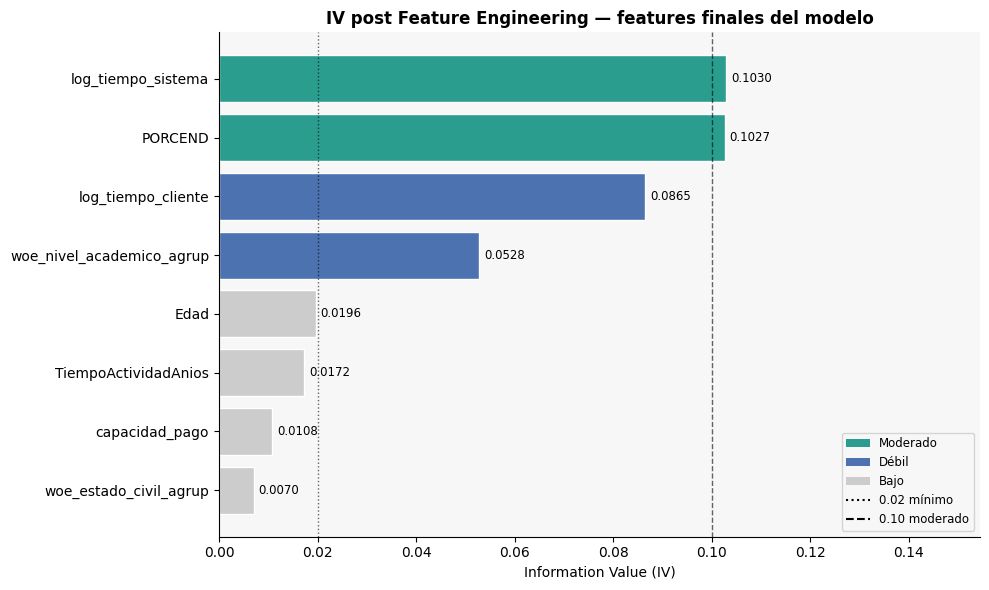

In [45]:
COLOR_IV = {
    "Moderado" : "#2A9D8F",
    "Débil"    : COLOR_BUENO,
    "Bajo"     : "#CCCCCC",
}

fig, ax = plt.subplots(figsize=(10, 6))
colores_iv = [COLOR_IV[c] for c in df_iv["clasificacion"]]
bars = ax.barh(df_iv["feature"], df_iv["IV"],
               color=colores_iv, edgecolor="white", linewidth=1)

for bar, (_, row) in zip(bars, df_iv.iterrows()):
    ax.text(row["IV"] + 0.001, bar.get_y() + bar.get_height()/2,
            f'{row["IV"]:.4f}', va="center", fontsize=8.5)

ax.axvline(0.02, color="black", linestyle=":",  linewidth=1,
           alpha=0.6, label="0.02 — mínimo")
ax.axvline(0.10, color="black", linestyle="--", linewidth=1,
           alpha=0.6, label="0.10 — moderado")

from matplotlib.patches import Patch
leyenda = [Patch(facecolor=c, label=l) for l, c in COLOR_IV.items()]
leyenda += [
    plt.Line2D([0],[0], color="black", linestyle=":",  label="0.02 mínimo"),
    plt.Line2D([0],[0], color="black", linestyle="--", label="0.10 moderado"),
]
ax.legend(handles=leyenda, loc="lower right", fontsize=8.5)

ax.set_xlabel("Information Value (IV)")
ax.set_title("IV post Feature Engineering — features finales del modelo",
             fontsize=12, fontweight="bold")
ax.invert_yaxis()
ax.set_xlim(0, df_iv["IV"].max() * 1.5)
plt.tight_layout()
plt.show()

### Interpretación

- **`PORCEND`, `log_tiempo_sistema`, `log_tiempo_cliente`** lideran el ranking con IV débil-moderado (~0.09–0.10). Son las señales más fuertes disponibles.
- **`woe_nivel_academico_agrup`** aporta señal real (IV=0.053) validando la agrupación de categorías.
- **`capacidad_pago` y `carga_total`** tienen IV bajo (< 0.01), consecuencia de que `GastosFamiliares` fue calculado automáticamente como 67% del ingreso en el sistema de originación. Aun así se mantienen porque pueden capturar interacciones en modelos de árboles.
- **`woe_Genero`, `es_cliente_nuevo`** muestran IV~0 en cálculo univariado, pero el WoE de Género sí mostró diferencia de mora (8% vs 14%) en el EDA. El IV puede subestimar variables binarias con distribución muy asimétrica.
- **Conclusión:** no hay degradación de señal respecto al EDA. El dataset de 9 features está listo para el modelado.


## 10. Exportar artefactos para el modelado

In [46]:
import pickle
from pathlib import Path

DIR_ART = Path("artefactos")
DIR_ART.mkdir(exist_ok=True)

COLS_MODELO   = FEATURES + [TARGET]
df_train_out  = df_train_fe[COLS_MODELO].copy()
df_test_out   = df_test_fe[COLS_MODELO].copy()

df_train_out.to_parquet(DIR_ART / "train_model.parquet", index=False)
df_test_out.to_parquet( DIR_ART / "test_model.parquet",  index=False)

with open(DIR_ART / "fe_fit_params.pkl", "wb") as f:
    pickle.dump(fit_params, f)

print(f"✓ Exportados en: {DIR_ART.resolve()}")
print(f"  train_model.parquet : {df_train_out.shape}")
print(f"  test_model.parquet  : {df_test_out.shape}")
print(f"  fe_fit_params.pkl   : WoE maps + estadísticos de train")
print(f"\nFeatures: {FEATURES}")

✓ Exportados en: C:\Users\Javier\Documents\Prueba DS\Solventa\artefactos
  train_model.parquet : (3452, 9)
  test_model.parquet  : (863, 9)
  fe_fit_params.pkl   : WoE maps + estadísticos de train

Features: ['log_tiempo_cliente', 'log_tiempo_sistema', 'PORCEND', 'capacidad_pago', 'woe_nivel_academico_agrup', 'woe_estado_civil_agrup', 'TiempoActividadAnios', 'Edad']
